# Deforestación Perú — Descarga y Exploración del GeoJSON

**Curso:** MIA-07 Redes Neuronales y Aprendizaje Profundo — Sección B  
**Proyecto final:** Detección de deforestación en imágenes satelitales

Este notebook hace lo siguiente:

1. Descarga `deforestacion.geojson` desde un bucket S3 público (`osmseed-dev/test/`).
2. Carga el archivo con `geopandas`.
3. Explora la estructura del dataset: CRS, columnas, número de polígonos, fuente, fechas, distribución geográfica.
4. Visualiza los polígonos en un mapa interactivo (`folium`) y en un plot estático (`matplotlib`).

El GeoJSON contiene polígonos de zonas deforestadas en el Perú, mapeadas por **SERFOR** (Servicio Nacional Forestal y de Fauna Silvestre). Servirá como **ground truth** (etiquetas) para entrenar la red U-Net que detectará deforestación a partir de imágenes Sentinel-2.

## 1. Instalación de dependencias

Si no tienes estas librerías, descomenta y ejecuta la celda.

In [1]:
# !pip install geopandas folium matplotlib requests

## 2. Descarga del GeoJSON desde S3 público

El archivo está alojado en:

```
s3://osmseed-dev/test/deforestacion.geojson
```

Como es un bucket público, se puede acceder vía HTTPS sin credenciales AWS.

In [2]:
from pathlib import Path
import requests

URL = "https://osmseed-dev.s3.amazonaws.com/test/deforestacion.geojson"
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_PATH = OUTPUT_DIR / "deforestacion.geojson"

if OUTPUT_PATH.exists():
    size_mb = OUTPUT_PATH.stat().st_size / 1e6
    print(f"✔ Archivo ya descargado: {OUTPUT_PATH} ({size_mb:.1f} MB)")
else:
    print(f"Descargando desde {URL} ...")
    with requests.get(URL, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(OUTPUT_PATH, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
    size_mb = OUTPUT_PATH.stat().st_size / 1e6
    print(f"✔ Descargado: {OUTPUT_PATH} ({size_mb:.1f} MB)")

✔ Archivo ya descargado: data/deforestacion.geojson (18.6 MB)


## 3. Carga con GeoPandas

`geopandas` lee GeoJSON directamente como un DataFrame con geometría.

In [3]:
import geopandas as gpd

gdf = gpd.read_file(OUTPUT_PATH)
print(f"Filas (polígonos): {len(gdf):,}")
print(f"CRS: {gdf.crs}")
print(f"Tipos de geometría: {gdf.geom_type.value_counts().to_dict()}")
print(f"Bounding box (lon_min, lat_min, lon_max, lat_max):\n  {gdf.total_bounds}")
gdf.head(3)

Filas (polígonos): 9,910
CRS: EPSG:4326
Tipos de geometría: {'MultiPolygon': 9910}
Bounding box (lon_min, lat_min, lon_max, lat_max):
  [-78.42624664 -14.07508973 -68.98965832  -0.23299341]


,OBJECTID,FUENTE,DOCREG,FECREG,OBSERV,ZONUTM,ORIGEN,REPOR,CODOBJ,FESATA,...,COORNO,TIPRO,ESTADO,Shape_STAr,Shape_STLe,ORIG_FID,contacto,correo,descarga,geometry
0,18885.0,UMS - SERFOR,None,None,Area de afectacion en la Zona Norte de la Pamp...,19,2,RCU_001_2017,1,2016-12-01,...,8.581084e+06,0,2.0,0.000002,0.008766,0,931381206,juan.suyo@geogpsperu.com,www.geogpsperu.com,"MULTIPOLYGON (((-69.9703 -12.83254, -69.9703 -..."
1,18886.0,UMS - SERFOR,None,None,Area de afectacion en la Zona Norte de la Pamp...,19,2,RCU_001_2017,2,2016-12-01,...,8.580587e+06,0,2.0,0.000007,0.025974,1,931381206,juan.suyo@geogpsperu.com,www.geogpsperu.com,"MULTIPOLYGON (((-69.97326 -12.83542, -69.97326..."
2,18887.0,UMS - SERFOR,None,None,Area de afectacion en la Zona Norte de la Pamp...,19,2,RCU_001_2017,3,2016-12-01,...,8.580393e+06,0,2.0,0.000002,0.007111,2,931381206,juan.suyo@geogpsperu.com,www.geogpsperu.com,"MULTIPOLYGON (((-69.98239 -12.83864, -69.98239..."


## 4. Exploración de columnas y atributos

In [4]:
print("Columnas disponibles:\n")
for col in gdf.columns:
    print(f"  - {col}")

Columnas disponibles:

  - OBJECTID
  - FUENTE
  - DOCREG
  - FECREG
  - OBSERV
  - ZONUTM
  - ORIGEN
  - REPOR
  - CODOBJ
  - FESATA
  - FESATB
  - SATELITE
  - SUPAFEC
  - DRIVER
  - VERAFECT
  - CATEG
  - NOMCATEG
  - DOCLEG
  - NOMTIT
  - DOCAUT
  - CPPCER
  - NOMDIS
  - NOMPRO
  - NOMDEP
  - COORES
  - COORNO
  - TIPRO
  - ESTADO
  - Shape_STAr
  - Shape_STLe
  - ORIG_FID
  - contacto
  - correo
  - descarga
  - geometry


In [5]:
# Fuente de los datos
print("FUENTE de los polígonos:")
print(gdf["FUENTE"].value_counts())

FUENTE de los polígonos:
FUENTE
UMS - SERFOR    9910
Name: count, dtype: int64


In [6]:
# Fechas de afectación (rango temporal del dataset)
import pandas as pd

gdf["FESATA_dt"] = pd.to_datetime(gdf["FESATA"], errors="coerce")
gdf["FESATB_dt"] = pd.to_datetime(gdf["FESATB"], errors="coerce")

print(f"Fecha satélite A — mínima: {gdf['FESATA_dt'].min()}")
print(f"Fecha satélite A — máxima: {gdf['FESATA_dt'].max()}")
print(f"Fecha satélite B — mínima: {gdf['FESATB_dt'].min()}")
print(f"Fecha satélite B — máxima: {gdf['FESATB_dt'].max()}")
print("\nDistribución por año de detección:")
print(gdf["FESATB_dt"].dt.year.value_counts().sort_index())

Fecha satélite A — mínima: 2016-12-01 00:00:00
Fecha satélite A — máxima: 2019-11-22 00:00:00
Fecha satélite B — mínima: 2017-07-04 00:00:00
Fecha satélite B — máxima: 2020-11-18 00:00:00

Distribución por año de detección:
FESATB_dt
2017.0    3431
2018.0    5845
2019.0      57
2020.0     445
Name: count, dtype: int64


In [7]:
# Superficie afectada (columna SUPAFEC, asumida en hectáreas)
print("Estadísticas de superficie afectada (SUPAFEC):")
print(gdf["SUPAFEC"].describe())
print(f"\nTotal de superficie afectada: {gdf['SUPAFEC'].sum():,.1f}")

Estadísticas de superficie afectada (SUPAFEC):
count    9910.000000
mean        4.804456
std        29.545831
min         0.000000
25%         0.080000
50%         0.300000
75%         1.030000
max       505.760000
Name: SUPAFEC, dtype: float64

Total de superficie afectada: 47,612.2


In [8]:
# Driver (causa) de la deforestación
if "DRIVER" in gdf.columns:
    print("Distribución de DRIVER (causa de deforestación):")
    print(gdf["DRIVER"].value_counts())

Distribución de DRIVER (causa de deforestación):
DRIVER
2    7192
1    1504
3    1206
8       8
Name: count, dtype: int64


## 5. Visualización geográfica

### 5.1 Plot estático con matplotlib

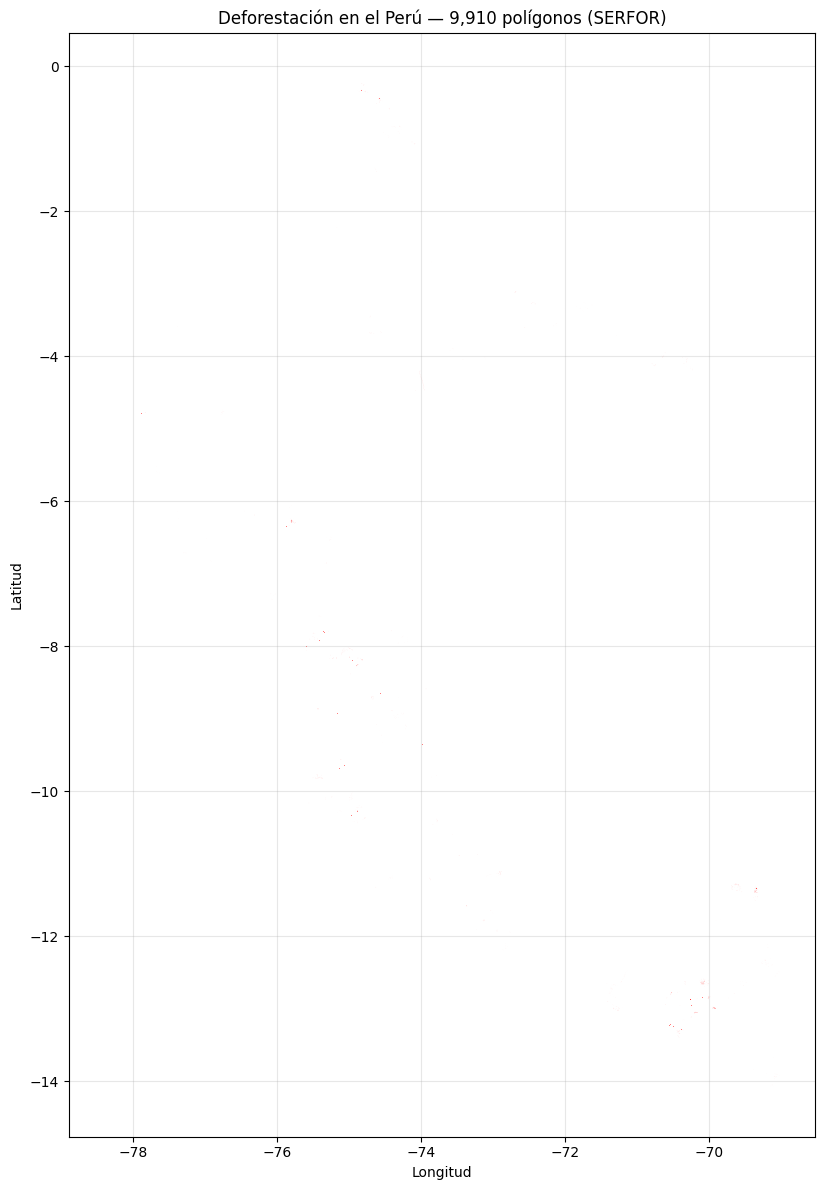

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))
gdf.plot(ax=ax, color="red", alpha=0.5, edgecolor="none", markersize=1)
ax.set_title(f"Deforestación en el Perú — {len(gdf):,} polígonos (SERFOR)")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/deforestacion_overview.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.2 Mapa interactivo con Folium

Mostramos solo una muestra de polígonos para no sobrecargar el mapa.

In [10]:
import folium

# Centro aproximado del bbox
minx, miny, maxx, maxy = gdf.total_bounds
center = [(miny + maxy) / 2, (minx + maxx) / 2]

m = folium.Map(location=center, zoom_start=6, tiles="OpenStreetMap")

# Tomamos una muestra para que el mapa no pese demasiado
# Convertimos columnas datetime a string (folium/json no las serializa)
sample = gdf.sample(n=min(500, len(gdf)), random_state=42).copy()
for col in sample.select_dtypes(include=['datetime64[ns]']).columns:
    sample[col] = sample[col].astype(str)

folium.GeoJson(
    sample.to_json(),
    name="Deforestación (muestra)",
    style_function=lambda x: {
        "fillColor": "#d62728",
        "color": "#7f0000",
        "weight": 0.5,
        "fillOpacity": 0.6,
    },
).add_to(m)

folium.LayerControl().add_to(m)
m.save("data/deforestacion_mapa.html")
m

## 6. Próximos pasos

Ya tenemos las **etiquetas** (polígonos de deforestación). Faltan los **inputs** (imágenes satelitales) y combinarlos para entrenar la red.

Los siguientes notebooks harán:

- `02_descarga_sentinel2.ipynb`: Descargar imágenes Sentinel-2 (RGB + NIR) de las mismas zonas y fechas usando Google Earth Engine o Sentinel Hub.
- `03_generar_mascaras.ipynb`: Rasterizar los polígonos de este GeoJSON sobre las imágenes Sentinel-2 → obtener máscaras binarias.
- `04_dataset_parches.ipynb`: Cortar imágenes y máscaras en parches de 256×256 → guardar como dataset PyTorch.
- `05_modelo_unet.ipynb`: Implementar y entrenar U-Net en PyTorch.
- `06_evaluacion.ipynb`: IoU, F1, Dice, visualizaciones.

### Schema sintético de la pipeline

```
GeoJSON (este notebook)  +  Sentinel-2 imagen
          ↓                          ↓
     rasterización             normalización
          ↓                          ↓
     máscara binaria  ─────►  parches 256x256
                                     ↓
                                  U-Net
                                     ↓
                          máscara predicha + IoU
```